In [46]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from hottbox.core import Tensor, TensorTKD
from hottbox.algorithms.decomposition import HOSVD, HOOI
from hottbox.utils.generation import residual_tensor
from coursework.data import get_image, plot_tensors

In [48]:
np.random.seed(0)

[Return to Table of Contents](./0_Table_of_contents.ipynb)

# Tucker Decomposition

<img src="./imgs/TensorTKD.png" alt="Drawing" style="width: 500px;"/>

In previous [assignment](./2_Efficient_representation_of_multidimensional_arrays.ipynb), you have been provided materials which cover efficient representations of mutlidimensional arrays of data, such as the Tucker form. In this module, you will take a closer look at it and the assiciated computational methods.


Any tensor of arbitrarily large order can be decomposed in the Tucker form. As illustrated above, a tensor $\mathbf{\underline{X}} \in \mathbb{R}^{I \times J \times K}$ can be represented as a dense core tensor $\mathbf{\underline{G}}$ and a set of factor matrices $\mathbf{A} \in \mathbb{R}^{I \times Q}, \mathbf{B} \in \mathbb{R}^{J \times R}$ and $\mathbf{C} \in
\mathbb{R}^{K \times P}$

$$
\mathbf{\underline{X}} = \mathbf{\underline{G}} \times_1 \mathbf{A} \times_2 \mathbf{B} \times_3 \mathbf{C} = \Big[    \mathbf{\underline{G}} ;  \mathbf{A},  \mathbf{B}, \mathbf{C}      \Big]
$$


On practice, there exist several computational methods to accomplish this all of which are combined into a Tucker Decomposition framework. The two most commonly used algorithms are:
1. Higher Order Singular Value Decomposition ([HOSVD](#Higher-Order-Singular-Value-Decomposition-(HOSVD)))
1. Higher Order Orthogonal Iteration ([HOOI](#Higher-Order-Orthogonal-Iteration-(HOOI)))


# Higher Order Singular Value Decomposition (HOSVD)

The HOSVD is a special case of the Tucker decomposition, in which all the factor matrices are constrained to be orthogonal. They are computed as truncated version of the left singular matrices of all possible mode-$n$ unfoldings of tensor $\mathbf{\underline{X}}$:

$$
\begin{aligned}
\mathbf{X}_{(1)} &= \mathbf{U}_1  \mathbf{\Sigma}_1 \mathbf{V}_1^T \quad \rightarrow \quad \mathbf{A} = \mathbf{U}_1[1:R_1]\\
\mathbf{X}_{(2)} &= \mathbf{U}_2  \mathbf{\Sigma}_2 \mathbf{V}_2^T \quad \rightarrow \quad \mathbf{B} = \mathbf{U}_2[1:R_2] \\
\mathbf{X}_{(3)} &= \mathbf{U}_3  \mathbf{\Sigma}_3 \mathbf{V}_3^T \quad \rightarrow \quad \mathbf{C} = \mathbf{U}_3[1:R_3] \\
\end{aligned}
$$

After factor matrices are obtained, the core tensor $\mathbf{\underline{G}}$ is computed as

$$
\mathbf{\underline{G}} = \mathbf{\underline{X}} \times_1 \mathbf{A}^T \times_2 \mathbf{B}^T \times_3 \mathbf{C}^T        
$$


# Higher Order Orthogonal Iteration (HOOI)

HOOI algorithm is another special case of the Tuker decomposition. Like HOSVD, it decomposes a tensor into a dense core tensor and orthogonal factor matrices. The difference between the two lies in the fact that in HOOI the factor matrices are optimized iteratively using an Alternating Least Squares (ALS) approach. In other words, the tucker representation $[ \mathbf{\underline{G}};\mathbf{A}^{(1)}, \mathbf{A}^{(2)}, \cdots,\mathbf{A}^{(N)} ]$ of the given tensor $\mathbf{\underline{X}}$ is obtained through the HOOI as follows

$$
\begin{aligned}
&\mathbf{\underline{Y}} = \mathbf{\underline{X}} \times_1 \mathbf{A}^{(1)T} \times_2 \cdots \times_{n-1} \mathbf{A}^{(n-1)T} \times_{n+1} \mathbf{A}^{(n+1)} \times \cdots \times_N \mathbf{A}^{(N)} \\
&\mathbf{A}^{(n)} \leftarrow R_n \text{ leftmost singular vectors of } \mathbf{Y}_{(n)}
\end{aligned}
$$

The above is repeated until convergence, then the core tensor $\mathbf{\underline{G}} \in \mathbb{R}^{R_1 \times R_2 \times \cdots \times R_N}$ is computed as

$$
\mathbf{\underline{G}} = \mathbf{\underline{X}} \times_1 \mathbf{A}^{(1)T}  \times_2 \mathbf{A}^{(2)T} \times_3 \cdots  \times_N \mathbf{A}^{(N)T}
$$

# Multi-linear rank

The **multi-linear rank** of a tensor $\mathbf{\underline{X}} \in \mathbb{R}^{I_1 \times \cdots \times I_N}$ is the $N$-tuple $(R_1, \dots, R_N)$ where each $R_n$ is the rank of the subspace spanned by mode-$n$ fibers, i.e. $R_n = \text{rank} \big( \mathbf{X}_{(n)} \big)$. Thus, for our order-$3$ tensor the multi-linear rank is $(R_1, R_2, R_3)$. Multi-linear rank provides flexibility in compression and approximation of the original tensor.

> **NOTE:** For a tensor of order $N$ the values $R_1, R_2, \dots , R_N$ are not necessarily the same, whereas, for matrices (tensors of order 2) the equality $R_1 = R_2$ always holds, where $R_1$ and $R_2$ are the matrix column rank and row rank respectively.



# Performing tensor decomposition

In [49]:
# Create tensor
I, J, K = 5, 6, 7
array_3d = np.random.rand(I * J * K).reshape((I, J, K)).astype(float)
tensor = Tensor(array_3d)

# Initialise algorithm
algorithm = HOSVD()

# Perform decomposing for selected multi-linear rank
ml_rank = (4, 5, 6)
tensor_tkd = algorithm.decompose(tensor, ml_rank)

# Result preview
print(tensor_tkd)

print('\n\tFactor matrices')
for mode, fmat in enumerate(tensor_tkd.fmat):
    print('Mode-{} factor matrix is of shape {}'.format(mode, fmat.shape))
    
print('\n\tCore tensor')
print(tensor_tkd.core)

Tucker representation of a tensor with multi-linear rank=(4, 5, 6).
Factor matrices represent properties: ['mode-0', 'mode-1', 'mode-2']
With corresponding latent components described by (5, 6, 7) features respectively.

	Factor matrices
Mode-0 factor matrix is of shape (5, 4)
Mode-1 factor matrix is of shape (6, 5)
Mode-2 factor matrix is of shape (7, 6)

	Core tensor
This tensor is of order 3 and consists of 120 elements.
Sizes and names of its modes are (4, 5, 6) and ['mode-0', 'mode-1', 'mode-2'] respectively.


# Evaluation and reconstruction

Tucker representation of an original tensor is almost always an approximation, regardless of which algorithm has been employed for performing decomposition. Thus, relative error of approximation is commonly used in order to evaluate performance of computational methods, i.e. the ratio between a Frobenious norms of residual and original tensors.

In [50]:
# Compute residual tensor
tensor_res = residual_tensor(tensor, tensor_tkd)

# Compute error of approximation
rel_error = tensor_res.frob_norm / tensor.frob_norm

print("Relative error of approximation = {}".format(rel_error))

Relative error of approximation = 0.21320264561618077


## **Assigment 1**

1. Create a tensor of order 4 with sizes of each mode being defined by prime numbers and  obtain a Tucker representation using HOOI algorithm with multi-linear (4, 10, 6, 2). Then calculation ratio between the number of elements in the original tensor and its Tucker form.

1. For a tensor that consists of 1331 elements, which multi-linear rank guarantees a perfect reconstruction from its Tucker form and why. Is such choice reasonable for practical applications?


### Solution: Part 1

In [51]:
# Create a tensor
# order 4, prime number size
I,J,K,W = 11,13,19,7 # require a large prime number otherwise the rank can not be satisfied

array_4d = np.random.rand(I*J*K*W).reshape((I,J,K,W))
tensor = Tensor(array_4d)
print(tensor)


This tensor is of order 4 and consists of 19019 elements.
Sizes and names of its modes are (11, 13, 19, 7) and ['mode-0', 'mode-1', 'mode-2', 'mode-3'] respectively.


In [52]:
# Perform decomposition HOOI
ML_rank = (4,10,6,2)

algorithm_HOOI = HOOI() # perform HOOI

tensor_HOOI = algorithm_HOOI.decompose(tensor, ML_rank)

print(tensor_HOOI)


print('\n\tFactor matrices')
for mode, fmat in enumerate(tensor_HOOI.fmat):
    print('Mode-{} factor matrix is of shape {}'.format(mode, fmat.shape))
    
print('\n\tCore tensor')
print(tensor_HOOI.core)

# check the ML rank is satisfied.

Tucker representation of a tensor with multi-linear rank=(4, 10, 6, 2).
Factor matrices represent properties: ['mode-0', 'mode-1', 'mode-2', 'mode-3']
With corresponding latent components described by (11, 13, 19, 7) features respectively.

	Factor matrices
Mode-0 factor matrix is of shape (11, 4)
Mode-1 factor matrix is of shape (13, 10)
Mode-2 factor matrix is of shape (19, 6)
Mode-3 factor matrix is of shape (7, 2)

	Core tensor
This tensor is of order 4 and consists of 480 elements.
Sizes and names of its modes are (4, 10, 6, 2) and ['mode-0', 'mode-1', 'mode-2', 'mode-3'] respectively.


In [53]:
# Print ratio
# Compute residual tensor
tensor_res = residual_tensor(tensor, tensor_HOOI)

# Compute error of approximation
rel_error = tensor_res.frob_norm / tensor.frob_norm

print("Relative error of approximation = {}".format(rel_error))

Relative error of approximation = 0.4909613873011859


### Solution: Part 2

**Include your answer with explanations here**


# Application: Image compression 

Color images can be naturally represented as a tensor of order three with the shape `(height x width x channels)` where channels are, for example, Red, Blue and Green (RGB)

<img src="./imgs/image_to_base_colors.png" alt="Drawing" style="width: 500px;"/>

By keeping its original structure, allows to apply methods from multi-linear analysis. For instance, we can employ algorithms for Tucker decompositions in order to commress oringinal informaiton by varying values of desired multi-linear rank.

```python
# Get data in form of a Tensor
car = get_image(item="car", view="top")
tensor = Tensor(car)

# Initialise algorithm and preform decomposition
algorithm = HOSVD()
tensor_tkd = algorithm.decompose(tensor, rank=(25, 25, 3))

# Evaluate result
tensor_res = residual_tensor(tensor, tensor_tkd)
rel_error = tensor_res.frob_norm / tensor.frob_norm

print("Relative error of approximation = {}".format(rel_error))
```

When can also visually inspect image obtained by reconstructing the Tucker representation
```python
# Reconstruction
tensor_rec = tensor_tkd.reconstruct()

# Plot original and reconstructed images side by side
plot_tensors(tensor, tensor_rec)
```

<img src="./imgs/car_orig_vs_reconstructed_25_25_3.png" alt="Drawing" style="width: 500px;"/>

## **Assigment 2**
For this assignment you are provided with function `get_image()` which requires two parameters: `item` and `view`. The valid values for former are **car** and **apple**, while the latter takes only **side** and **top**. 

1. Use multi-linear rank equal to `(50, 50, 2)` in order to obtain Tucker representations of images of the car and apple. Analyse results by visually inspecting their reconstructions.

1. Use multi-linear rank equal to `(50, 50, 2)` in order to obtain Tucker representations of images of the apple taken from the top and from the side. Analyse results by visually inspecting their reconstructions.

1. What would happen to the reconstruction if the value of multi-linear rank corresponding to the channel mode is decreased to 1.


### Solution: Part 1

In [54]:
# Create tensors from images
LM_rank = (50,50,2)
car = get_image(item="car", view="side")
car_tensor  = Tensor(car)

apple = get_image(item='apple', view='side')
apple_tensor  = Tensor(apple)

In [55]:
# Perform decomposition
algorithm = HOOI()

## car
tensor_tkd_car = algorithm.decompose(car_tensor, rank=LM_rank)

# Evaluate result
tensor_res_car = residual_tensor(car_tensor, tensor_tkd_car)
rel_error_car = tensor_res_car.frob_norm / car_tensor.frob_norm

print("Relative error of approximation of car image = {}".format(rel_error_car))


## apple
tensor_tkd_apple = algorithm.decompose(apple_tensor, rank=LM_rank)

# Evaluate result
tensor_res_apple = residual_tensor(apple_tensor, tensor_tkd_apple)
rel_error_apple = tensor_res_apple.frob_norm / apple_tensor.frob_norm

print("Relative error of approximation of apple image = {}".format(rel_error_apple))

Relative error of approximation of car image = 0.04020380557257631
Relative error of approximation of apple image = 0.0656123187572973


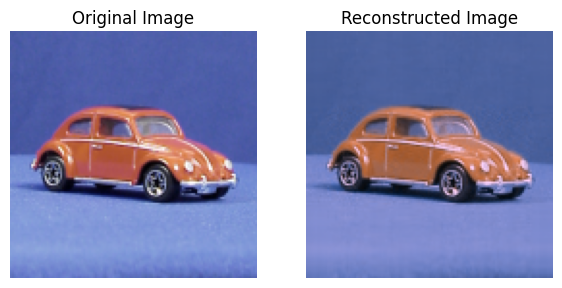

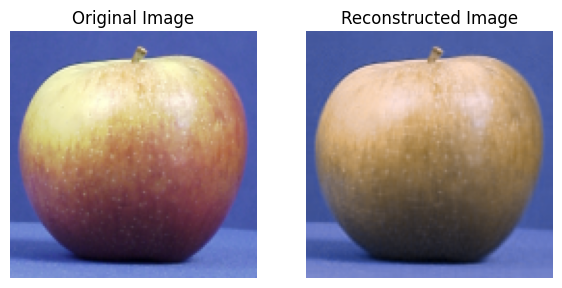

In [56]:
# Evaluate results
# Reconstruction
tensor_rec_car = tensor_tkd_car.reconstruct()

# Plot original and reconstructed images side by side
plot_tensors(car_tensor, tensor_rec_car)

# Reconstruction
tensor_rec_apple = tensor_tkd_apple.reconstruct()

# Plot original and reconstructed images side by side
plot_tensors(apple_tensor, tensor_rec_apple)

**Include your explanations here**

From the result, the reconstructed car image has a lower color saturation comapre to orginal image, where the intensity of red and blue color is decreased. Comapre with apple image, the reconstructed apple does not show the red color, which means the red color information is lost during the decomposition process to Tucker form. Because the apple image contain more information, and some color like yellow is a combination of gree and red. When the red information is lost, only the green color information is left, that why the reconstucted apple image is mainly green. The apple reconstructed image have higher error than the car error. Therefore, the car image decmposition outperform the apple image decmposition. The loss of red color is because the channel mode is 2, since only 2 values are used to represent a pixel value, then some color like red would lost and unable to perform.


### Solution: Part 2

In [57]:
# Create tensors from images
LM_rank = (50,50,2)
apple_side = get_image(item="apple", view="side")
apple_side_tensor  = Tensor(apple_side)

apple_Top = get_image(item='apple', view='top')
apple_Top_tensor  = Tensor(apple_Top)

In [58]:
# Perform decomposition
algorithm = HOSVD()

## car
tensor_tkd_apple_side = algorithm.decompose(apple_side_tensor, rank=LM_rank)

# Evaluate result
tensor_res_apple_side = residual_tensor(apple_side_tensor, tensor_tkd_apple_side)
rel_error_apple_side = tensor_res_apple_side.frob_norm / apple_side_tensor.frob_norm

print("Relative error of approximation of apple side image = {}".format(rel_error_apple_side))


## apple
tensor_tkd_apple_top = algorithm.decompose(apple_Top_tensor, rank=LM_rank)

# Evaluate result
tensor_res_apple_top = residual_tensor(apple_Top_tensor, tensor_tkd_apple_top)
rel_error_apple_top = tensor_res_apple_top.frob_norm / apple_Top_tensor.frob_norm

print("Relative error of approximation of apple top image = {}".format(rel_error_apple_top))

Relative error of approximation of apple side image = 0.06574690406026336
Relative error of approximation of apple top image = 0.03706225838740844


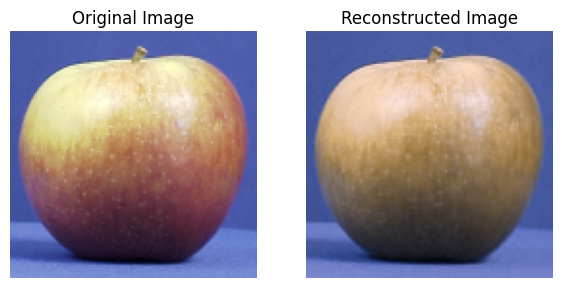

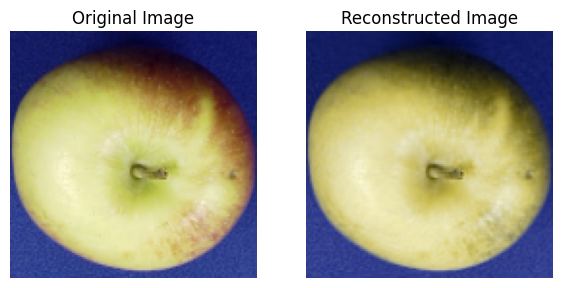

In [59]:
# Evaluate results
# Reconstruction
tensor_rec_apple_side = tensor_tkd_apple_side.reconstruct()

# Plot original and reconstructed images side by side
plot_tensors(apple_side_tensor, tensor_rec_apple_side)

# Reconstruction
tensor_rec_apple_top = tensor_tkd_apple_top.reconstruct()

# Plot original and reconstructed images side by side
plot_tensors(apple_Top_tensor, tensor_rec_apple_top)

**Include your explanations here**

For the top apple image, since the image is mainly green and mix with some red and background is blue. The reconstructed image lost all red color information during the transformation into Tucker format, and reconstructed image onlt have green color on the apple itself with purely blue background. This suggest that if there is only one color, such as the blue background, although reconstruction might loss some information but it able to maintain the overall blue color. On the other hand, when there is highly mix of color such as side apple image. The decomposition unable to maintain all the information, and lost the red color in this case, result a low satutated color side image. When more color information is mixed, the error become large. So the error in side apple image is higher than the apple top image.

### Solution: Part 3

**Include your explanations here**


If decrease to 1, then the reconstructed image is black and white since it only able to distinguish whether is black or white, and it is a single value pixel rather than a matrix in original image. And a single pixel is unable to represent the color spectrum and impossible to perform color like red, blue and green which require matrix pixel represtation. Unless the image is monochromatic, and it result the reconstructed image have different shaded area on it.